In [1]:
from datetime import datetime
from pathlib import Path

from astropy.time import Time
from astropy.coordinates import AltAz, SkyCoord, EarthLocation
from astropy import units as u
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib.dates as mdates

import eigsep_data as ed  # available from https://github.com/EIGSEP/data-analysis
import hera_filters  # available from https://github.com/HERA-Team/hera_filters

%matplotlib widget

/home/christian/Documents/research/papers/eigsep_instrument/.venv/lib/python3.12/site-packages/pyuvdata/analytic_beam.py:174: UserWarning: basis_vector_type was not defined, defaulting to azimuth and zenith_angle.
  warnings.warn(
/home/christian/Documents/research/papers/eigsep_instrument/.venv/lib/python3.12/site-packages/matvis/__init__.py:3: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution


In [2]:
d = np.load("virA_fringes.npz")
davg = d["davg"]  # data
tavg = d["tavg"]  # timestamps (Utah time = UTC-6)
freq = d["freq"]  # frequencies (MHz)
dts = [datetime.fromtimestamp(t) for t in tavg]
df = 1e6 * (freq[1] - freq[0])  # in Hz
dtavg = tavg[1] - tavg[0]

In [3]:
def wfall(data, mode="log", vmin=1e-1, vmax=1e3, ytime=False):
    if mode == "log":
        dp = np.log10(np.abs(data))
        if vmin is not None:
            vmin = np.log10(vmin)
        if vmax is not None:
            vmax = np.log10(vmax)
    elif mode == "abs":
        dp = np.abs(data)
    else:
        dp = data.copy()
    plt.figure(figsize=(12, 8))
    extent = [freq.min(), freq.max(), len(data), 0]
    plt.ylabel("Time [cnt]")
    
    plt.imshow(dp, aspect="auto", interpolation="nearest", cmap="plasma", vmin=vmin, vmax=vmax, extent=extent)
    plt.xlabel("Frequency [MHz]")
    plt.colorbar()
    plt.show()

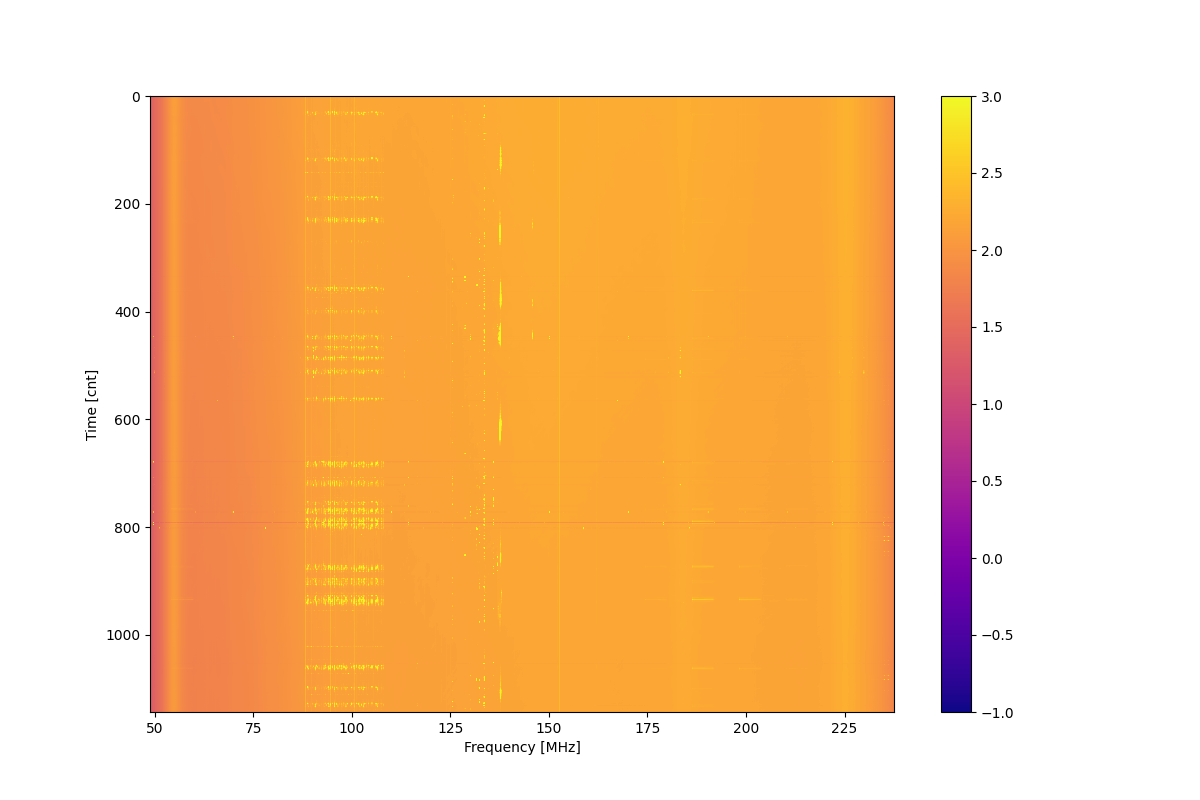

In [4]:
# raw data
wfall(davg)

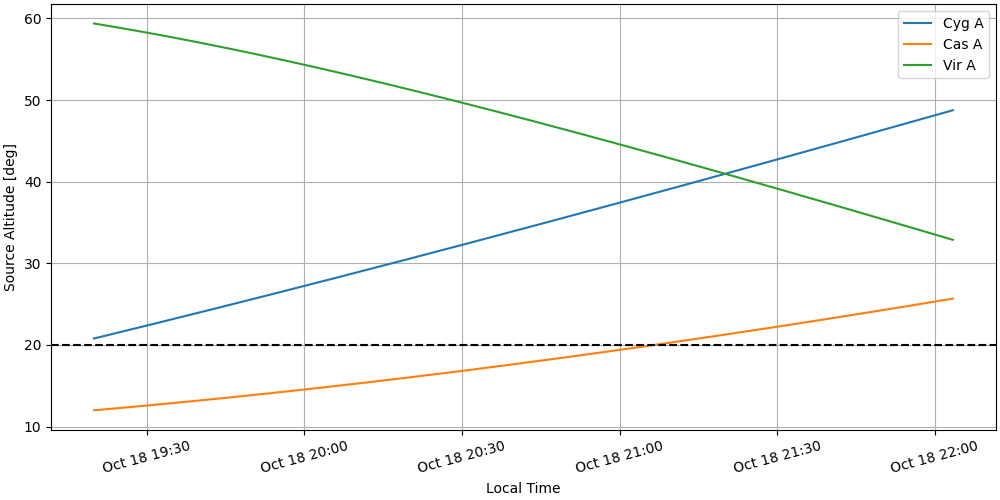

In [5]:
# location of point sources
LAT = 39.2477
LON = -113.4033

def sources(lon_deg, lat_deg, times):
    """
    lon_deg, lat_deg: observer longitude (East +) and latitude in degrees
    time: must be able to instantiate astropy.Time
    """
    loc = EarthLocation(lat=lat_deg*u.deg, lon=lon_deg*u.deg)
    obstime = Time(times)
    altaz_frame = AltAz(obstime=obstime, location=loc)

    alts = {}
    azs = {}
    for name in ["Cyg A", "Cas A", "Vir A"]:
        c = SkyCoord.from_name(name).transform_to(altaz_frame)
        alts[name] = c.alt.to(u.deg).value
        azs[name] = c.az.to(u.deg).value
    return alts, azs

alts, azs = sources(LON, LAT, dts)



plt.figure(figsize=(10, 5), constrained_layout=True)
for k, v in alts.items():
    plt.plot(dts, v, label=k)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %d %H:%M'))
plt.xticks(rotation=15)
plt.grid()
plt.axhline(20, ls="--", c="k")
plt.legend()
plt.xlabel("Local Time")
plt.ylabel("Source Altitude [deg]")
plt.show()

## Flag RFI

In [6]:
def plot_spec(data, mask, model=None, noise_model=None, log=True):
    plt.figure()
    plt.plot(freq, data, label="Data")
    if model is not None:
        plt.plot(freq, model, label="Model")
        plt.plot(freq, np.abs((data - model)*mask), label="Residual")
        if noise_model is not None:
            plt.plot(freq, noise_model, label="Noise Model")
    else:
        plt.plot(freq, data * mask, label="Masked")
    if log:
        plt.yscale("log")
    plt.xlabel("Frequency [MHz]")
    plt.ylabel("Amplitude")
    plt.legend()
    plt.show()

### Median Flagger

/tmp/ipykernel_107216/2694713423.py:3: RuntimeWarning: divide by zero encountered in log10
  dp = np.log10(np.abs(data))


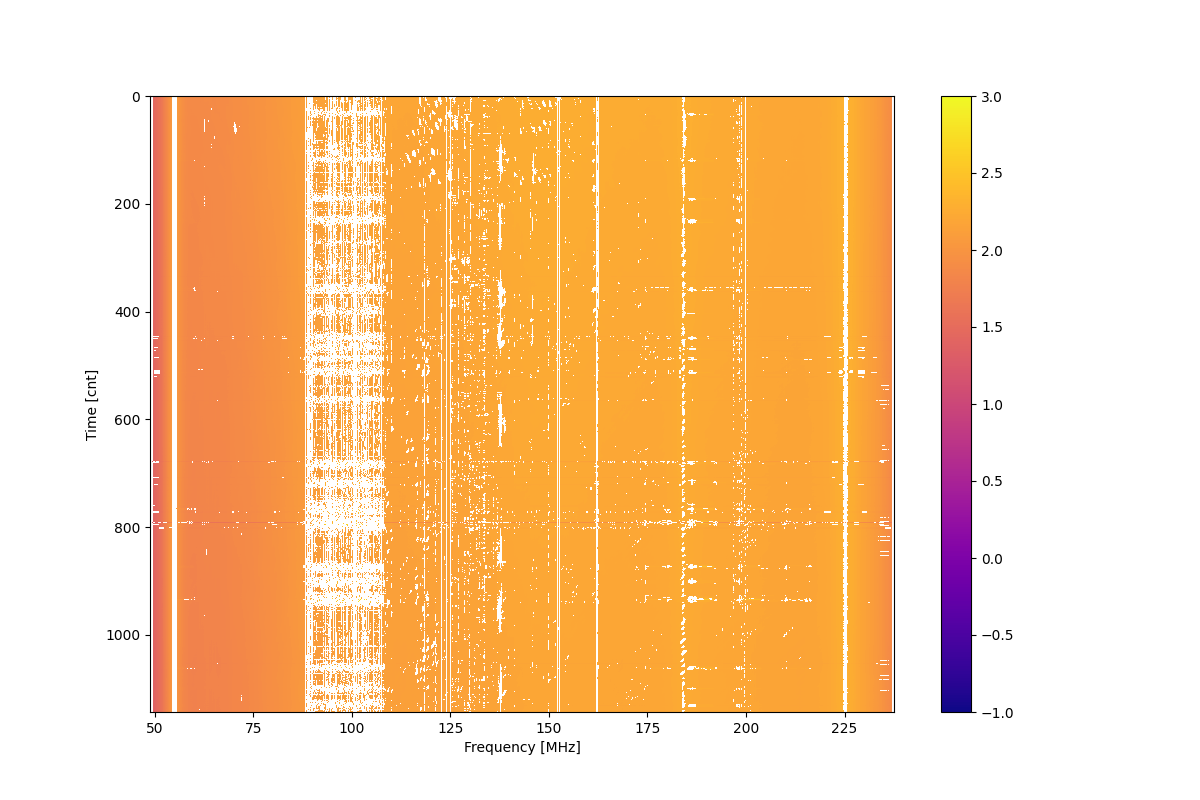

In [7]:
mad_flags, mad_z = ed.rfi.median_flagger(davg, nsig=10, kernel_half_width=5, return_z=True)
wfall(davg * ~mad_flags)

### Mean Flagger

In [8]:
# noise estimate from radiometer eq
noise = davg / np.sqrt(df * dtavg)
mean_flags = ed.rfi.mean_flagger(davg, noise, nsig=15, flags=mad_flags)
mean_flags = ed.rfi.broadcast_flags(mean_flags)

/tmp/ipykernel_107216/2694713423.py:3: RuntimeWarning: divide by zero encountered in log10
  dp = np.log10(np.abs(data))


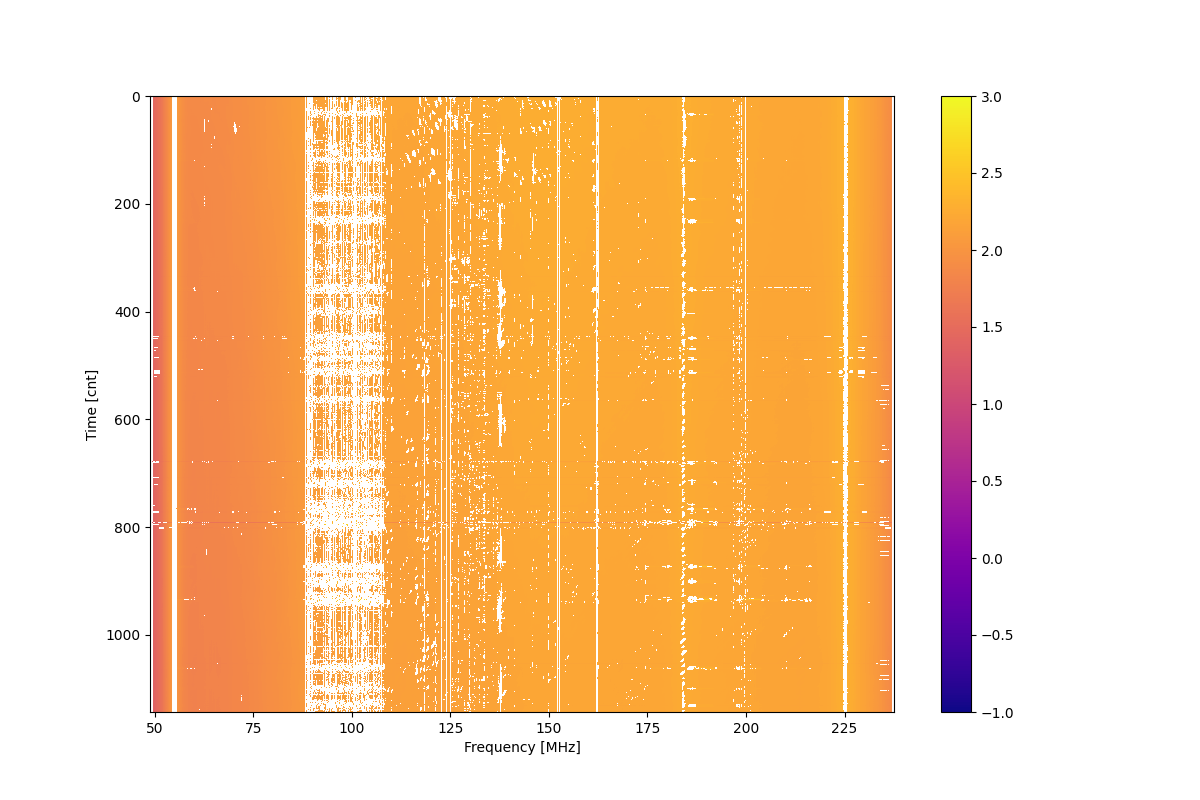

/tmp/ipykernel_107216/2694713423.py:3: RuntimeWarning: divide by zero encountered in log10
  dp = np.log10(np.abs(data))


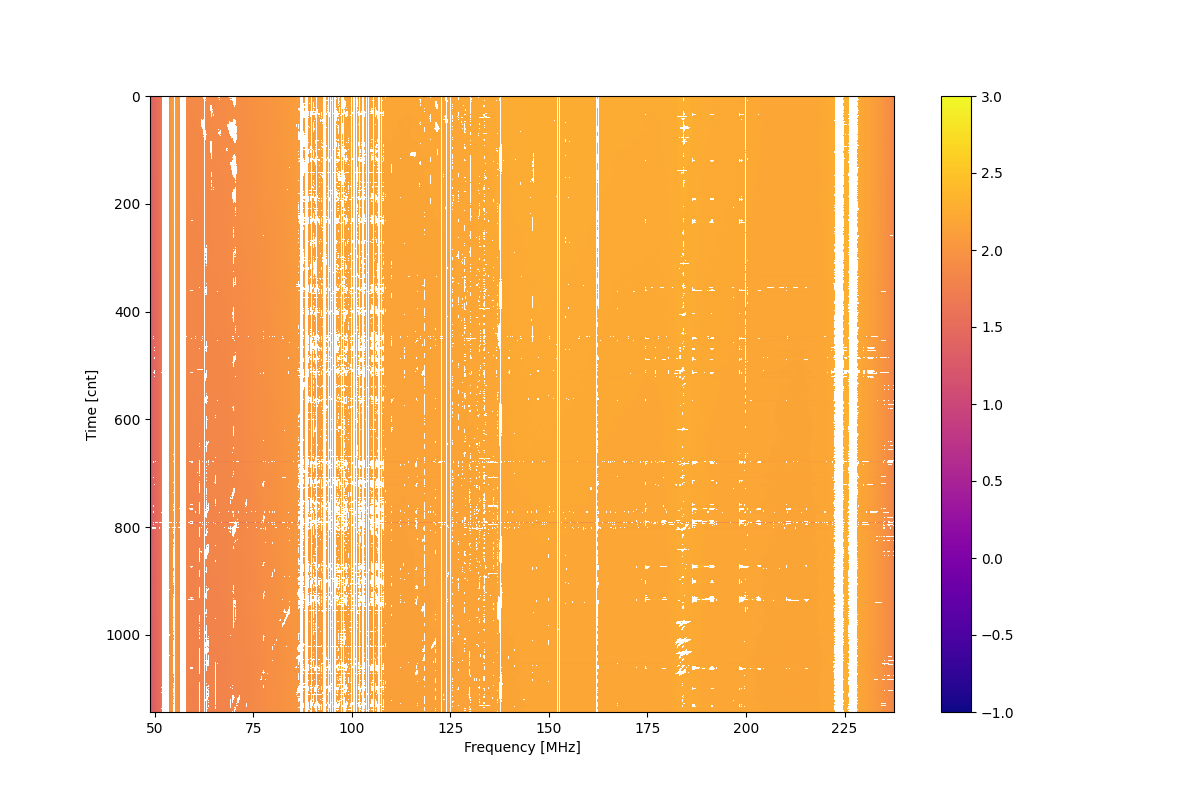

In [9]:
wfall(davg * ~mad_flags)
wfall(davg * ~mean_flags)

### DPSS Flagger

In [10]:
# filter up to 300ns with eval_cutoff of 1e-9
dpss_flags, dmdl, nmdl = ed.rfi.dpss_flagger(davg, noise, freq*1e6, [0], [300e-9], flags=mean_flags, nsig=25, mode="dpss_matrix", eigenval_cutoff=[1e-9], return_models=True)
dpss_flags = ed.rfi.broadcast_flags(mean_flags | dpss_flags)

/home/christian/Documents/research/papers/eigsep_instrument/.venv/lib/python3.12/site-packages/hera_filters/dspec.py:2166: ComplexWarning: Casting complex values to real discards the imaginary part
  model[i], _, info_t = _fit_basis_1d(x=x[1], y=_y, w=_w, filter_centers=filter_centers[1],


/tmp/ipykernel_107216/2694713423.py:3: RuntimeWarning: divide by zero encountered in log10
  dp = np.log10(np.abs(data))


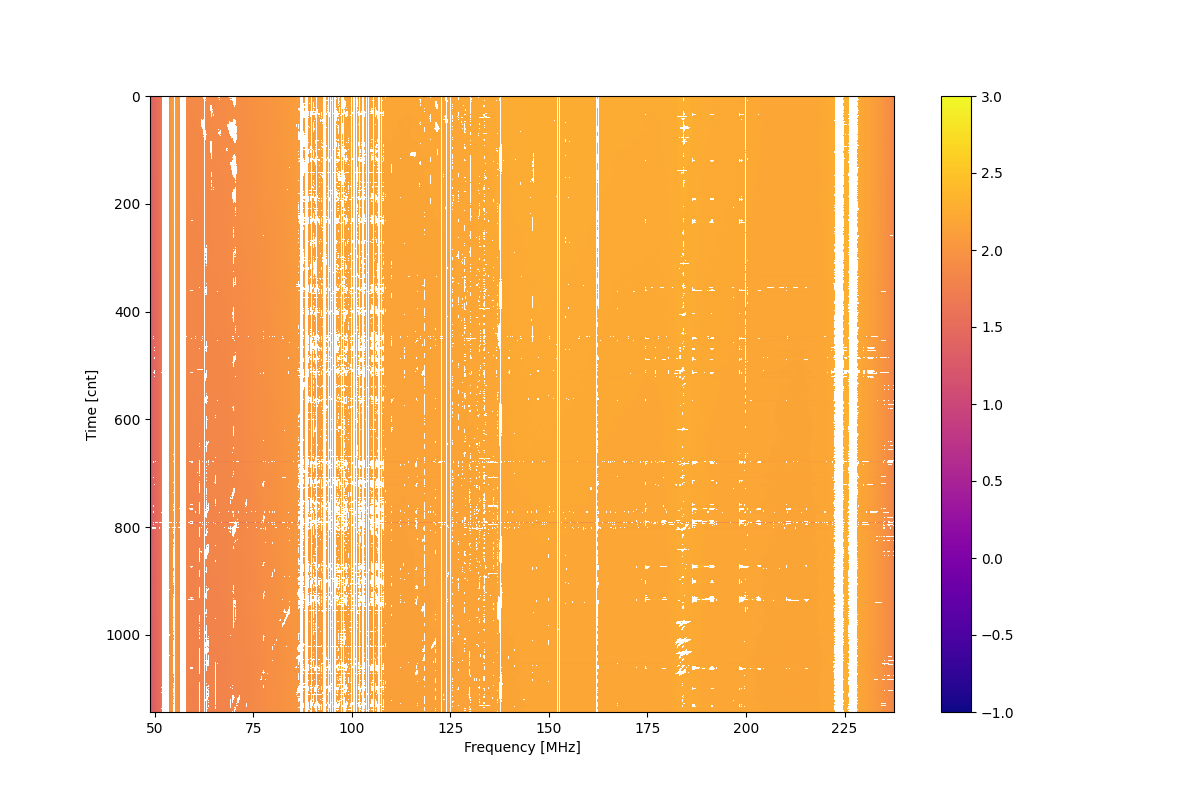

/tmp/ipykernel_107216/2694713423.py:3: RuntimeWarning: divide by zero encountered in log10
  dp = np.log10(np.abs(data))


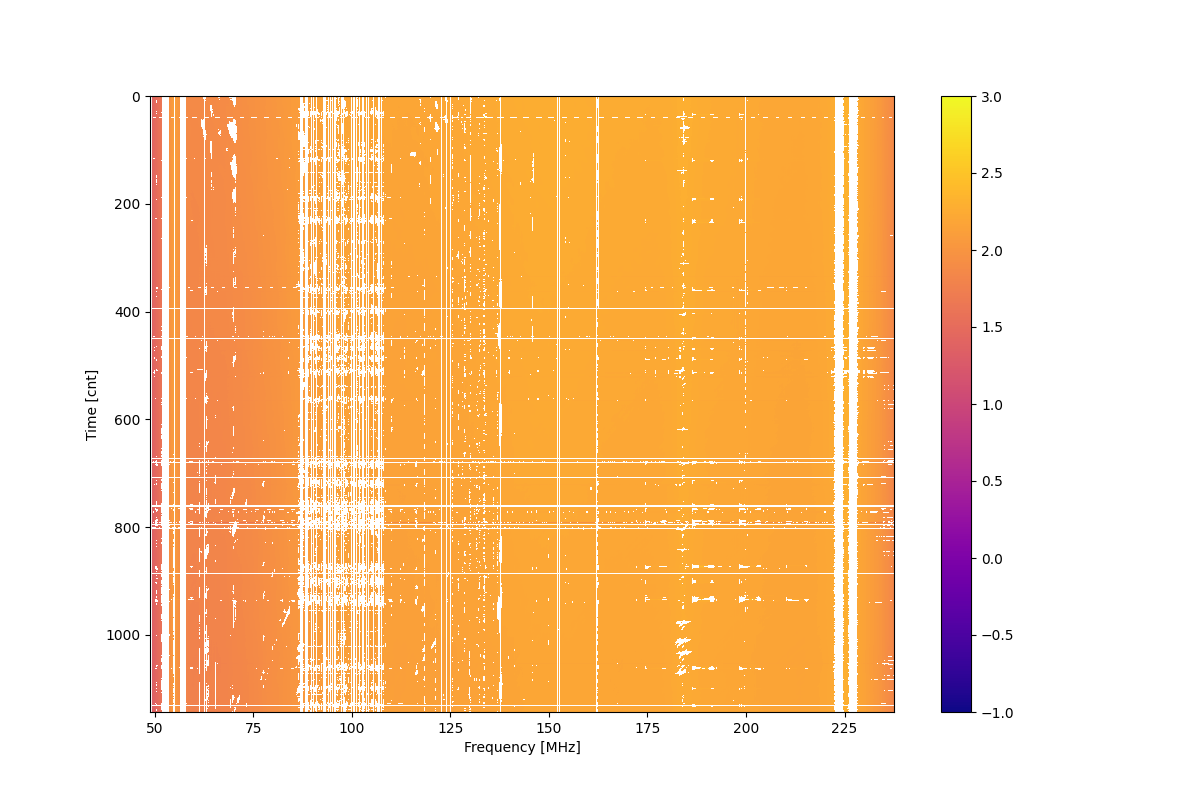

In [11]:
wfall(davg * ~mean_flags)
wfall(davg * ~dpss_flags)

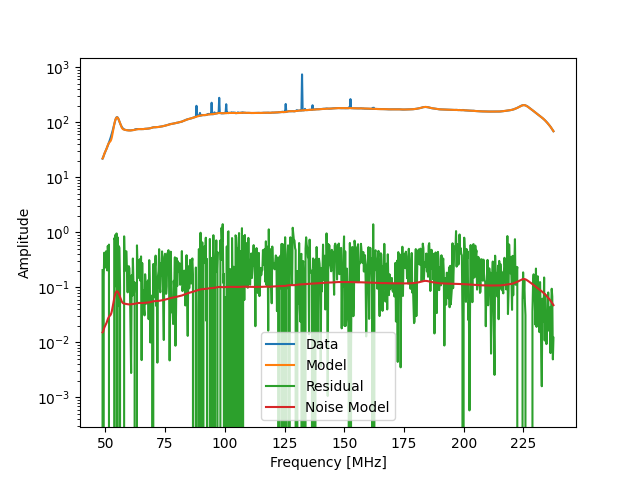

In [12]:
plot_spec(davg[300], ~dpss_flags[300], model=dmdl[300], noise_model=nmdl[300])

Use flags to improve model with second fit.

In [13]:
# second iteration, tighter nsig cut
_, dmdl, nmdl = ed.rfi.dpss_flagger(davg, noise, freq*1e6, [0], [300e-9], flags=dpss_flags, nsig=20, mode="dpss_matrix", eigenval_cutoff=[1e-9], return_models=True)

/tmp/ipykernel_107216/2694713423.py:3: RuntimeWarning: divide by zero encountered in log10
  dp = np.log10(np.abs(data))


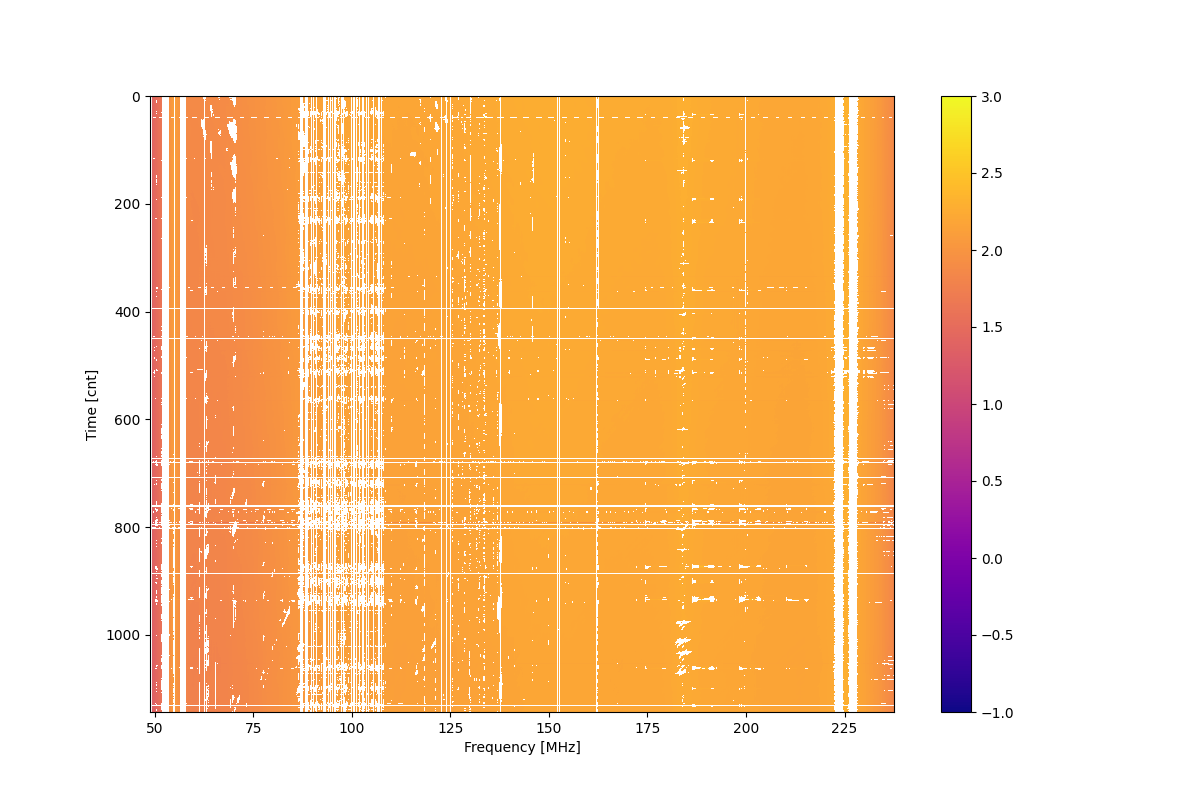

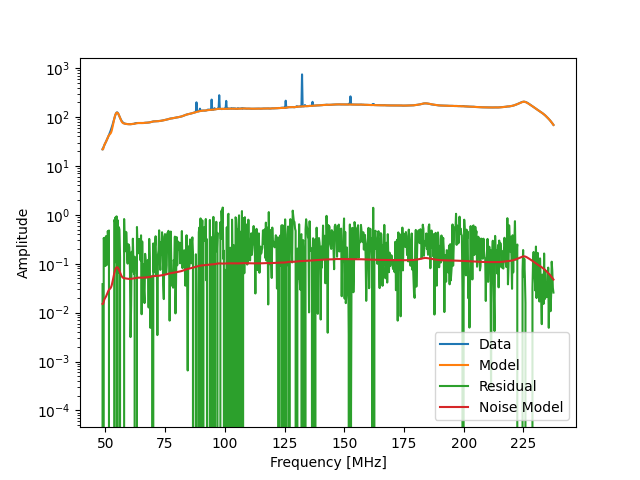

In [14]:
wfall(davg * ~dpss_flags)
plot_spec(davg[300], ~dpss_flags[300], model=dmdl[300], noise_model=nmdl[300])

## Delay transform

In [15]:
def dly_transform(d, freq, dmdl, mask=None):
    df = freq[1]-freq[0]  # mhz
    delay = np.fft.fftfreq(freq.size, d=df*1e-3)  # nanoseconds
    window = hera_filters.dspec.gen_window('bh7', freq.size)
    extent = [delay[0], delay[-1], len(davg), 0]
    if mask is None:
        mask = np.ones_like(d)
    res = (d - dmdl) * mask  # set residual to 0 in flagged channel == replace data with model
    _d = np.fft.fft(window[None] * res, axis=1)
    return _d, delay

In [16]:
_d, dly = dly_transform(davg, freq, dmdl, mask=~dpss_flags)
# subtract mean in each delay bin
_davg = _d - _d.mean(axis=0)
dplot = np.abs(_davg[350:])

In [17]:
# update plot parameters
FONTSIZE = 8 

plt.rc('font', size=FONTSIZE)          # controls default text sizes
plt.rc('axes', titlesize=FONTSIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=FONTSIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=FONTSIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=FONTSIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=FONTSIZE)    # legend fontsize


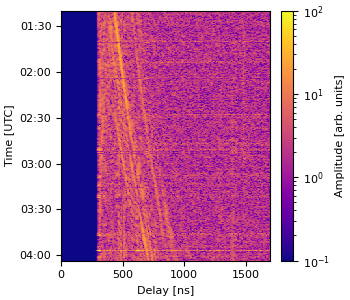

In [18]:
# add 6hrs to get UTC
tstart_dt = datetime.fromtimestamp(tavg[0]+6*3600)
tend_dt = datetime.fromtimestamp(tavg[-1]+6*3600)

extent = [0, dly.max(), tend_dt, tstart_dt]
vmin = 1e-1
vmax = 1e2

plt.figure(figsize=(3.5, 3.), constrained_layout=True)
plt.imshow(dplot[:, dly>0], cmap='plasma', interpolation='none', aspect='auto', extent=extent, norm=colors.LogNorm(vmin=vmin, vmax=vmax))
plt.xlabel("Delay [ns]")
plt.ylabel("Time [UTC]")
plt.gca().yaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
plt.colorbar(label="Amplitude [arb. units]")
plt.xlim(0, 1700)
#plt.savefig("/home/christian/Downloads/point_src.pdf", bbox_inches="tight")
plt.show()